Importing Required Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Loading dataset

In [ ]:
df=pd.read_csv('advertising_sales_data.csv')
df.drop(columns = ['Campaign'], inplace = True)
df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


Filling the Missing Values

In [ ]:
df['Radio'].fillna(df['Radio'].mean(), inplace=True)
print(df.isnull().sum())

TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64


/tmp/ipykernel_431/3892404983.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Radio'].fillna(df['Radio'].mean(), inplace=True)


Splitting the dataset into features(X) and target variable(Y)

In [ ]:
X=df.iloc[:,:-1].values
y=df.iloc[:,-1].values

Splitting the dataset into Training and Testing Sets

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=1)

Building Simple Linear Regression Model

In [ ]:
from sklearn.linear_model import LinearRegression
regressor=LinearRegression()
regressor.fit(X_train,y_train)
#Predicting the test set
y_pred = regressor.predict(X_test)

Visualizing the training set results

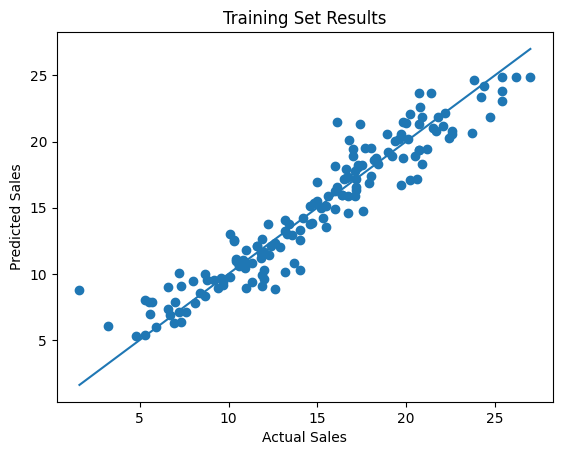

In [ ]:
y_train_pred = regressor.predict(X_train)
plt.scatter(y_train, y_train_pred)
plt.plot([y_train.min(), y_train.max()],
         [y_train.min(), y_train.max()])

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Training Set Results")

plt.show()

Visualizing the Test Set Results

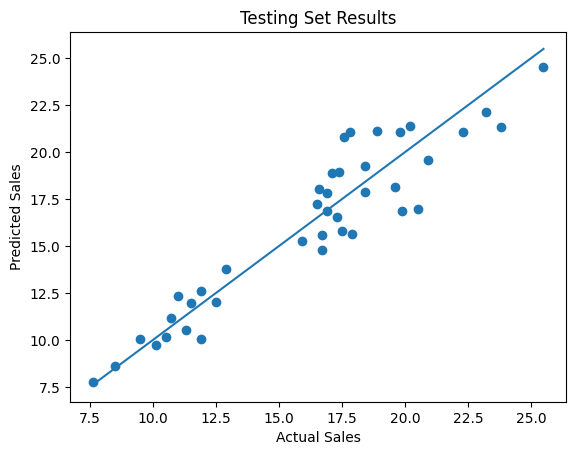

In [ ]:
plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()])

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Testing Set Results")

plt.show()

Calculating MSE for this model

In [ ]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test, y_pred)
print("MSE:", mse)

MSE: 2.4092185773771497


What is the average amount spent on TV advertising in the dataset?

In [ ]:
df['TV'].mean()
#The average amount spent on TV advertising in the dataset is approximately 147.04 units.
#This value represents the mean of all TV advertising expenditures across the dataset.

np.float64(147.0425)

What is the correlation between radio advertising expenditure and product sales?

In [ ]:
df['Radio'].corr(df['Sales'])
#The correlation between radio advertising expenditure and product sales is approximately 0.35, indicating a moderate positive relationship.
#This means that as radio advertising spending increases, sales tend to increase as well, but the relationship is not very strong.

np.float64(0.3496507429302875)

Which advertising medium has the highest impact on sales based on the dataset?

In [ ]:
df.corr()['Sales']
#TV advertising has the highest impact on sales, as it shows the strongest positive correlation with sales (approximately 0.9) compared to radio and newspaper advertising.
#This indicates that increases in TV advertising expenditure lead to a more significant rise in sales.

,Sales
TV,0.901208
Radio,0.349651
Newspaper,0.157960
Sales,1.000000


How would sales be predicted for a new set of advertising expenditures: 200 on TV, 40 on Radio, and 50 on Newspaper in dollars?

ANSWER: Sales are predicted using the trained linear regression model by substituting the new advertising values into the model’s learned equation. The model has the form:

Sales = b₀ + b₁(TV) + b₂(Radio) + b₃(Newspaper)

where b₀ is the intercept and b₁, b₂, b₃ are coefficients learned during training.
By inputting TV = 200, Radio = 40, and Newspaper = 50 into this equation, the model calculates the predicted sales value. In practice, this is done using the model’s predict() function.

In [ ]:
new_data = [[200, 40, 50]]  # TV, Radio, Newspaper
predicted_sales = regressor.predict(new_data)
print(predicted_sales)

[19.7321937]


How does the performance of the linear regression model change when the dataset is normalized?

In [ ]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()

X_train_scaled = sc.fit_transform(X_train)
X_test_scaled = sc.transform(X_test)

model2 = LinearRegression()
model2.fit(X_train_scaled, y_train)

y_pred2 = model2.predict(X_test_scaled)

mse_new = mean_squared_error(y_test, y_pred2)
print("MSE after normalization:", mse_new)

#The MSE values before and after normalization are almost identical, indicating that normalization does not significantly affect the performance of the linear regression model.
#This is because linear regression depends on the relationship between variables rather than their scale.

MSE after normalization: 2.4092185773771484


What is the impact on the sales prediction when only radio and newspaper advertising expenditures are used as predictors?

In [ ]:
X_reduced = df.iloc[:, [1,2]].values

X_train2, X_test2, y_train2, y_test2 = train_test_split(X_reduced, y, test_size=0.2, random_state=0)

model_reduced = LinearRegression()
model_reduced.fit(X_train2, y_train2)

y_pred_reduced = model_reduced.predict(X_test2)
mse_reduced = mean_squared_error(y_test2, y_pred_reduced)
print("MSE (Radio + Newspaper):", mse_reduced)
#The Mean Squared Error (MSE) increases when only radio and newspaper are used as predictors, indicating poorer model performance.
#This shows that TV advertising is a crucial variable for accurately predicting sales, and excluding it leads to higher prediction error.
#The increase in MSE confirms that the reduced model loses important information, resulting in less accurate predictions compared to the full model.

MSE (Radio + Newspaper): 31.445856585170986
